# Phase 3 — ViRGo-SAGE: GNN encoder over the virtual graphs

Trains an **unsupervised GraphSAGE** (`encoder.py`) on the **saved Phase-2 virtual graphs**; evaluates node classification + leakage-free link prediction. Only the encoder changes vs Phase 2: Skipgram lookup table → message passing.

- **Reads, never builds:** virtual graphs from `output/notebook2_create_vir_graph/virtual_graphs/<dataset>/k<K>/<sim>/`, LP splits from `splits/link_prediction/virtual_graph_study/`. Missing ⇒ run notebook 2 first.

Design: `docs/phase3_gnn_design.md` · Spine: README Phase 3.


In [1]:
"""Setup: repo root, config, knobs. This notebook reads Phase-2 artifacts; it builds no graphs."""
import os, sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)                     # run everything from the repo root
sys.path[:0] = [str(Path.cwd()), str(Path.cwd() / "scripts")]

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import benchmark_config as cfg
import eval_nodeclass, eval_linkpred, results_io
from encoder import SageEncoder
from virtual_graph import VirtualGraph

DATASET = "proteins"                                    # <-- pick the dataset (same knob as Phase 2)
SIM, K = "psi", 10                                  # <-- ONE graph for the spine sections 1-6 (K must be a single int); the K sweep has its own knobs: SWEEP_KS (section 8), SHOW_K (7), XD_K (9), RQ_K (11)
SEEDS = [42, 43, 44]                                # <-- pick seeds manually; keep [42, 43, 44] to match the bridge for fair comparison
POSITIVES = "edge"                                  # <-- ablation A (DECIDED: edge won): "edge" = direct virtual edges | "walk" = A1 walk co-occurrence
AGG = "mean"                                        # <-- ablation B (DECIDED: mean won): "mean" | "weighted" | "sum" | "max"
FEATURES = "all"                                    # <-- ablation D input features (D0 default): "all" | "degree" | "deg_cent" | "psi" | "random" (control) | "const"
P = cfg.GNN_PARAMS                                  # single source of truth (scripts/benchmark_config.py) - loads GNN settings
FORCE_REBUILD = False                               # False = reuse saved .emb if present

# Output zones (notebook-first layout): folder names the notebook, task, dataset, K, variant; file names the encoder + seed.
NB2 = Path("output") / "notebook2_create_vir_graph"       # read-only here: virtual graphs + DeepWalk bridge embeddings
NB3 = Path("output") / "notebook3_gnn_encoder"            # this notebook's embeddings
LP_SPLITS = Path("splits") / "link_prediction" / "virtual_graph_study"   # shared per-seed split folders (made by notebook 2)

ENCODER = (("graphsage_walk" if POSITIVES == "walk" else "graphsage_edge") + ("" if AGG == "mean" else f"_{AGG}")
           + ("" if FEATURES == "all" else f"_feat_{FEATURES}"))
# ENCODER is both the .emb filename prefix and the scoreboard name — every ablation writes its own files, nothing overwrites.
print(f"dataset={DATASET}  sim={SIM}  K={K}  seeds={SEEDS}  positives={POSITIVES}  agg={AGG}  features={FEATURES}  ({ENCODER})")
print(P)

dataset=proteins  sim=psi  K=10  seeds=[42, 43, 44]  positives=edge  agg=mean  features=all  (graphsage_edge)
{'hidden': 64, 'dimensions': 64, 'layers': 2, 'agg': 'mean', 'lr': 0.01, 'epochs': 50, 'negatives': 5, 'pairs_per_epoch': 100000, 'max_pairs': 2000000, 'positives': 'edge', 'features': 'all'}


/home/m-adam/miniconda/envs/i2v/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Load the graphs

Original graph from `input/` (node set + features); **saved** virtual graph from Phase 2. Missing file ⇒ run notebook 2.


In [2]:
"""Load original graph + the SAVED Phase-2 virtual graph."""
G = nx.read_edgelist(cfg.dataset(DATASET)["edgelist"], nodetype=int, create_using=nx.Graph())

vpath = NB2 / "virtual_graphs" / DATASET / f"k{K}" / SIM / "virtual_graph.edgelist"
assert vpath.exists(), f"{vpath} missing -> run notebooks/2-phase_2_virtual_graph.ipynb first (it builds + saves the virtual graphs)"
V = nx.read_weighted_edgelist(vpath, nodetype=int)
V.add_nodes_from(G.nodes)                           # edgelists omit isolated nodes -> restore the full node set
print(f"original: {G.number_of_nodes()} nodes / {G.number_of_edges()} edges")
print(f"virtual({SIM}, K={K}): {V.number_of_nodes()} nodes / {V.number_of_edges()} edges  <- {vpath}")

original: 43466 nodes / 81044 edges
virtual(psi, K=10): 43466 nodes / 317786 edges  <- output/notebook2_create_vir_graph/virtual_graphs/proteins/k10/psi/virtual_graph.edgelist


## 2 · Train (GraphSAGE → embeddings)

- `POSITIVES` — ablation A, **decided: `edge`** (positives = virtual edges; `walk` = Phase-2-comparable corpus).
- `AGG` — ablation B, **decided: `mean`** (beat weighted / sum / max).
- `FEATURES` — ablation D, all features for GraphSAGE


train seed 42 (edge positives, mean agg, all features) ...
  epoch   0 | loss 35.7180
  epoch  10 | loss 7.1666
  epoch  20 | loss 4.7525
  epoch  30 | loss 4.2778
  epoch  40 | loss 4.0700
  epoch  49 | loss 4.0164
saved output/notebook3_gnn_encoder/node_classification/proteins/k10/psi/graphsage_edge_s42.emb
train seed 43 (edge positives, mean agg, all features) ...
  epoch   0 | loss 31.2455
  epoch  10 | loss 5.9707
  epoch  20 | loss 4.5684
  epoch  30 | loss 4.1624
  epoch  40 | loss 4.0436
  epoch  49 | loss 4.0119
saved output/notebook3_gnn_encoder/node_classification/proteins/k10/psi/graphsage_edge_s43.emb
train seed 44 (edge positives, mean agg, all features) ...
  epoch   0 | loss 33.0711
  epoch  10 | loss 6.4676
  epoch  20 | loss 4.4839
  epoch  30 | loss 4.1588
  epoch  40 | loss 4.0437
  epoch  49 | loss 3.9997
saved output/notebook3_gnn_encoder/node_classification/proteins/k10/psi/graphsage_edge_s44.emb


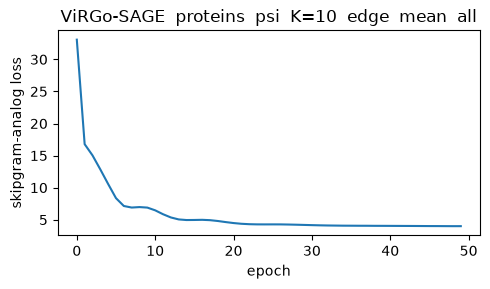

In [3]:
"""Train ViRGo-SAGE per seed on the full virtual graph; reuse saved .emb when present."""
losses = None
for seed in SEEDS:
    out = NB3 / "node_classification" / DATASET / f"k{K}" / SIM / f"{ENCODER}_s{seed}.emb"
    if out.exists() and not FORCE_REBUILD:
        print(f"reuse {out}")
        continue
    print(f"train seed {seed} ({POSITIVES} positives, {AGG} agg, {FEATURES} features) ...")
    enc = SageEncoder(G, V, seed, hidden=P["hidden"], dimensions=P["dimensions"], layers=P["layers"], agg=AGG, feats=FEATURES)
    losses = enc.train(P["epochs"], lr=P["lr"], negatives=P["negatives"],
                       pairs_per_epoch=P["pairs_per_epoch"], max_pairs=P["max_pairs"], positives=POSITIVES)
    enc.save(out)
    print(f"saved {out}")

if losses:                                          # spine check: the loss must fall
    plt.figure(figsize=(5, 3))
    plt.plot(losses)
    plt.xlabel("epoch"); plt.ylabel("skipgram-analog loss"); plt.title(f"ViRGo-SAGE  {DATASET}  {SIM}  K={K}  {POSITIVES}  {AGG}  {FEATURES}")
    plt.tight_layout(); plt.show()

## 3 · Verify the embeddings

Every node embedded · all values finite · readable by the same gensim loader the evals use.


In [4]:
"""Spine checks: node count, finiteness, loader compatibility."""
from gensim.models import KeyedVectors
for seed in SEEDS:
    out = NB3 / "node_classification" / DATASET / f"k{K}" / SIM / f"{ENCODER}_s{seed}.emb"
    kv = KeyedVectors.load_word2vec_format(str(out))
    assert len(kv) == G.number_of_nodes(), f"{out.name}: {len(kv)} vectors != {G.number_of_nodes()} nodes"
    assert np.isfinite(kv.vectors).all(), f"{out.name}: non-finite values"
    print(f"PASS {out.name}: {len(kv)} nodes x {kv.vectors.shape[1]}d, finite")

PASS graphsage_edge_s42.emb: 43466 nodes x 64d, finite
PASS graphsage_edge_s43.emb: 43466 nodes x 64d, finite
PASS graphsage_edge_s44.emb: 43466 nodes x 64d, finite


## 4 · Node classification (weighted F1)

One-vs-rest logistic regression on the embeddings, stratified 70/30, per seed — protocol identical to Phase 2 / I2V.


In [5]:
"""Node classification on the SAGE embeddings — protocol identical to Phase 2."""
labels = cfg.dataset(DATASET)["labels"]
nc_rows = []
if labels is None or not Path(labels).exists():
    print(f"{DATASET}: no labels -> node classification skipped")
else:
    for seed in SEEDS:
        emb = NB3 / "node_classification" / DATASET / f"k{K}" / SIM / f"{ENCODER}_s{seed}.emb"
        f1s, n, c = eval_nodeclass.evaluate(str(emb), str(labels), train_frac=cfg.REPRO["nodeclass_train_frac"], seed=seed)
        nc_rows.append({"encoder": ENCODER, "sim": SIM, "K": K, "seed": seed, "task": "nodeclass", "metric": f1s["weighted"]})
        print(f"seed {seed}: weighted F1 = {f1s['weighted']:.4f}  (n={n}, classes={c})")
    vals = [r["metric"] for r in nc_rows]
    print(f"\nNC weighted F1 = {np.mean(vals):.4f} ± {np.std(vals):.4f}")

seed 42: weighted F1 = 0.5534  (n=43466, classes=3)
seed 43: weighted F1 = 0.5588  (n=43466, classes=3)
seed 44: weighted F1 = 0.5580  (n=43466, classes=3)

NC weighted F1 = 0.5567 ± 0.0024


## 5 · Link prediction (AUC, leakage-free)

Same Phase-2 splits. Per seed: 70% `train.edgelist` → deterministically rebuild the train virtual graph → train SAGE on it → score held-out edges. Test edges never touch training.


In [6]:
"""Leakage-free LP: same Phase-2 splits, train-virtual rebuilt from the 70% edges, SAGE trained on it."""
lp_rows = []
for seed in SEEDS:
    split_dir = LP_SPLITS / DATASET / f"seed_{seed}"
    train_edges = split_dir / "train.edgelist"
    assert train_edges.exists(), f"{train_edges} missing -> run the Phase-2 notebook LP section first (shared splits = fair comparison)"
    emb = NB3 / "link_prediction" / DATASET / f"k{K}" / SIM / f"{ENCODER}_s{seed}.emb"
    if not emb.exists() or FORCE_REBUILD:
        print(f"train LP seed {seed} ({POSITIVES} positives, {AGG} agg, {FEATURES} features) ...")
        Gt = nx.read_edgelist(train_edges, nodetype=int, create_using=nx.Graph())
        Vt = VirtualGraph(Gt).build(SIM, K)               # deterministic rebuild from the 70% train edges only
        enc = SageEncoder(Gt, Vt, seed, hidden=P["hidden"], dimensions=P["dimensions"], layers=P["layers"], agg=AGG, feats=FEATURES)
        enc.train(P["epochs"], lr=P["lr"], negatives=P["negatives"],
                  pairs_per_epoch=P["pairs_per_epoch"], max_pairs=P["max_pairs"], positives=POSITIVES)
        enc.save(emb)
    else:
        print(f"reuse {emb}")
    auc = eval_linkpred.evaluate(str(emb), str(split_dir), seed=seed, score=cfg.REPRO["linkpred_score"])
    lp_rows.append({"encoder": ENCODER, "sim": SIM, "K": K, "seed": seed, "task": "linkpred", "metric": auc})
    print(f"seed {seed}: AUC = {auc:.4f}")
vals = [r["metric"] for r in lp_rows]
print(f"\nLP AUC = {np.mean(vals):.4f} ± {np.std(vals):.4f}")

train LP seed 42 (edge positives, mean agg, all features) ...
  epoch   0 | loss 35.4848
  epoch  10 | loss 7.4911
  epoch  20 | loss 4.7438
  epoch  30 | loss 4.2595
  epoch  40 | loss 4.0587
  epoch  49 | loss 4.0082
seed 42: AUC = 0.5598
train LP seed 43 (edge positives, mean agg, all features) ...
  epoch   0 | loss 29.6478
  epoch  10 | loss 5.8951
  epoch  20 | loss 4.5089
  epoch  30 | loss 4.1548
  epoch  40 | loss 4.0270
  epoch  49 | loss 4.0023
seed 43: AUC = 0.5620
train LP seed 44 (edge positives, mean agg, all features) ...
  epoch   0 | loss 32.5718
  epoch  10 | loss 6.3987
  epoch  20 | loss 4.4608
  epoch  30 | loss 4.1512
  epoch  40 | loss 4.0351
  epoch  49 | loss 3.9898
seed 44: AUC = 0.5548

LP AUC = 0.5588 ± 0.0030


## 6 · DeepWalk (Phase 2) vs GraphSAGE (Phase 3)

Both encoders scored **here, the same way**, from their saved `.emb` files — same virtual graph, same splits, same seeds.

`improvement` = GraphSAGE − DeepWalk.

`winner` = higher score.

Missing file ⇒ the cell names the notebook to run. Saved to `results/snapshots/<dataset>_encoder_comparison_K<K><suffix>.csv`; rows also recorded to the scoreboard.


In [7]:
"""One final table: DeepWalk (Phase 2) vs GraphSAGE (Phase 3), both scored here from their saved embeddings."""
labels = cfg.dataset(DATASET)["labels"]
have_labels = labels is not None and Path(labels).exists()
NC, LP = "node classification (weighted F1)", "link prediction (AUC)"

def task_scores(zone, encoder_name, notebook):
    """Score one encoder's saved .emb files with the shared eval protocol -> {task: [score per seed]}."""
    got = {NC: [], LP: []}
    for seed in SEEDS:
        emb = {"node_classification": zone / "node_classification" / DATASET / f"k{K}" / SIM / f"{encoder_name}_s{seed}.emb",
               "link_prediction":     zone / "link_prediction" / DATASET / f"k{K}" / SIM / f"{encoder_name}_s{seed}.emb"}
        if have_labels:
            assert emb["node_classification"].exists(), f"{emb['node_classification']} missing -> run {notebook} with the same DATASET/SIM/K/SEEDS first"
            f1s, _, _ = eval_nodeclass.evaluate(str(emb["node_classification"]), str(labels), train_frac=cfg.REPRO["nodeclass_train_frac"], seed=seed)
            got[NC].append(f1s["weighted"])
        assert emb["link_prediction"].exists(), f"{emb['link_prediction']} missing -> run {notebook} with the same DATASET/SIM/K/SEEDS first"
        got[LP].append(eval_linkpred.evaluate(str(emb["link_prediction"]), str(LP_SPLITS / DATASET / f"seed_{seed}"),
                                              seed=seed, score=cfg.REPRO["linkpred_score"]))
    return got

bridge = task_scores(NB2, "deepwalk", "notebooks/2-phase_2_virtual_graph.ipynb (sections 7-8)")
sage = task_scores(NB3, ENCODER, "sections 2-5 above (same POSITIVES/AGG knobs)")

comp = pd.DataFrame([{"task": t,
                      "deepwalk_phase2": round(float(np.mean(bridge[t])), 4),
                      f"{ENCODER}_phase3": round(float(np.mean(sage[t])), 4),
                      "improvement": round(float(np.mean(sage[t]) - np.mean(bridge[t])), 4),
                      "winner": ENCODER if np.mean(sage[t]) > np.mean(bridge[t]) else "deepwalk"}
                     for t in (NC, LP) if sage[t]])
out = Path("results") / "snapshots"; out.mkdir(parents=True, exist_ok=True)
suffix = ("" if POSITIVES == "walk" else f"_{POSITIVES}") + ("" if AGG == "mean" else f"_{AGG}")   # each ablation snapshot gets its own file
comp_csv = out / f"{DATASET}_encoder_comparison_K{K}{suffix}.csv"
comp.to_csv(comp_csv, index=False)
print(f"{DATASET} | virtual graph: {SIM}, K={K} | positives: {POSITIVES} | agg: {AGG} | seeds: {SEEDS} | same graph, same splits — only the encoder differs")
print(f"saved -> {comp_csv}")
display(comp)

for enc_name, got in (("deepwalk", bridge), (ENCODER, sage)):   # every run also lands in the accumulating scoreboard
    for t in (NC, LP):
        if got[t]:
            results_io.record_score(DATASET, enc_name, SIM, K, t, SEEDS, got[t])
print("recorded -> results/scoreboard.csv  (section 7 shows every variant tested so far)")

proteins | virtual graph: psi, K=10 | positives: edge | agg: mean | seeds: [42, 43, 44] | same graph, same splits — only the encoder differs
saved -> results/snapshots/proteins_encoder_comparison_K10_edge.csv


,task,deepwalk_phase2,graphsage_edge_phase3,improvement,winner
0,node classification (weighted F1),0.4877,0.5567,0.0690,graphsage_edge
1,link prediction (AUC),0.5222,0.5588,0.0366,graphsage_edge


recorded -> results/scoreboard.csv  (section 7 shows every variant tested so far)


## 7 · Detailed graph/encoder comparison

Tables compare the two headline encoders only: **`deepwalk` vs `graphsage_edge`**.

Workflow: run the sweep (§8) or new Setup knobs (§1–6) → rerun this section.


proteins MAIN RESULTS (K=[10]): 20 scores = 2 encoders x 5 virtual graphs x 2 tasks  -> complete grid, nothing missing

=== node classification (weighted F1) ===


,graph_variant,K,deepwalk,graphsage_edge,improvement,winner
0,psi,10,0.4877,0.5567,0.0690,graphsage_edge
1,degree,10,0.5153,0.5581,0.0428,graphsage_edge
2,centrality,10,0.4826,0.5536,0.0710,graphsage_edge
3,original,10,0.5256,0.5797,0.0541,graphsage_edge
4,hybrid,10,0.4944,0.5647,0.0703,graphsage_edge



=== link prediction (AUC) ===


,graph_variant,K,deepwalk,graphsage_edge,improvement,winner
0,psi,10,0.5222,0.5588,0.0366,graphsage_edge
1,degree,10,0.5045,0.5500,0.0455,graphsage_edge
2,centrality,10,0.5216,0.5829,0.0613,graphsage_edge
3,original,10,0.9414,0.6726,-0.2688,deepwalk
4,hybrid,10,0.8029,0.5633,-0.2396,deepwalk


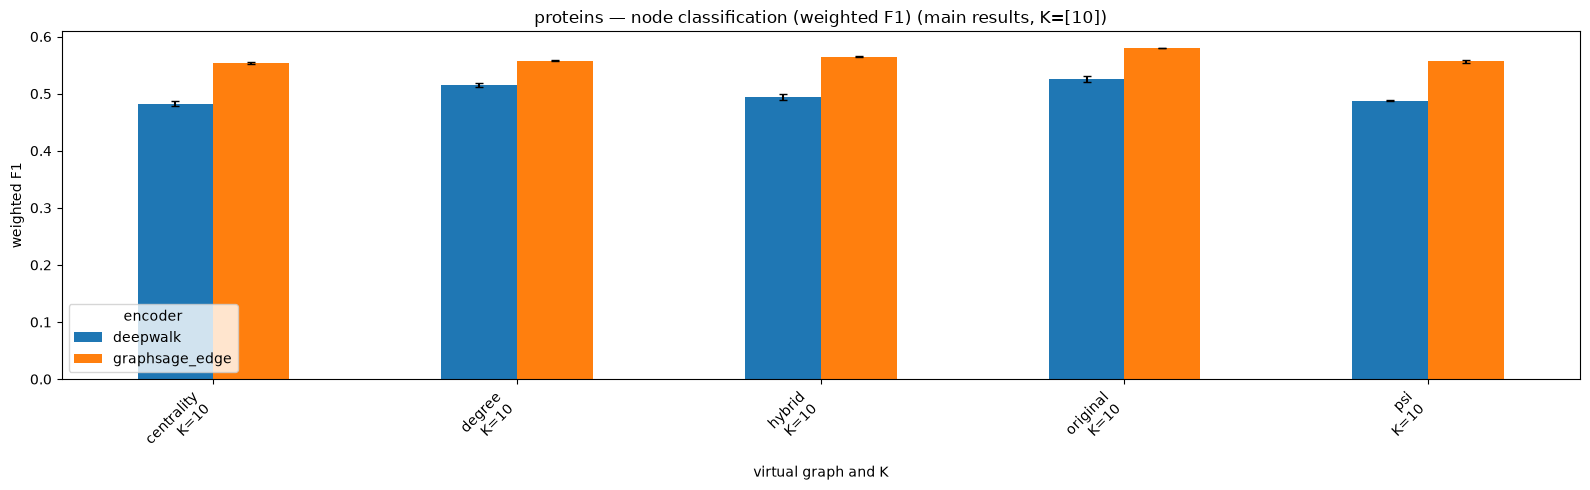

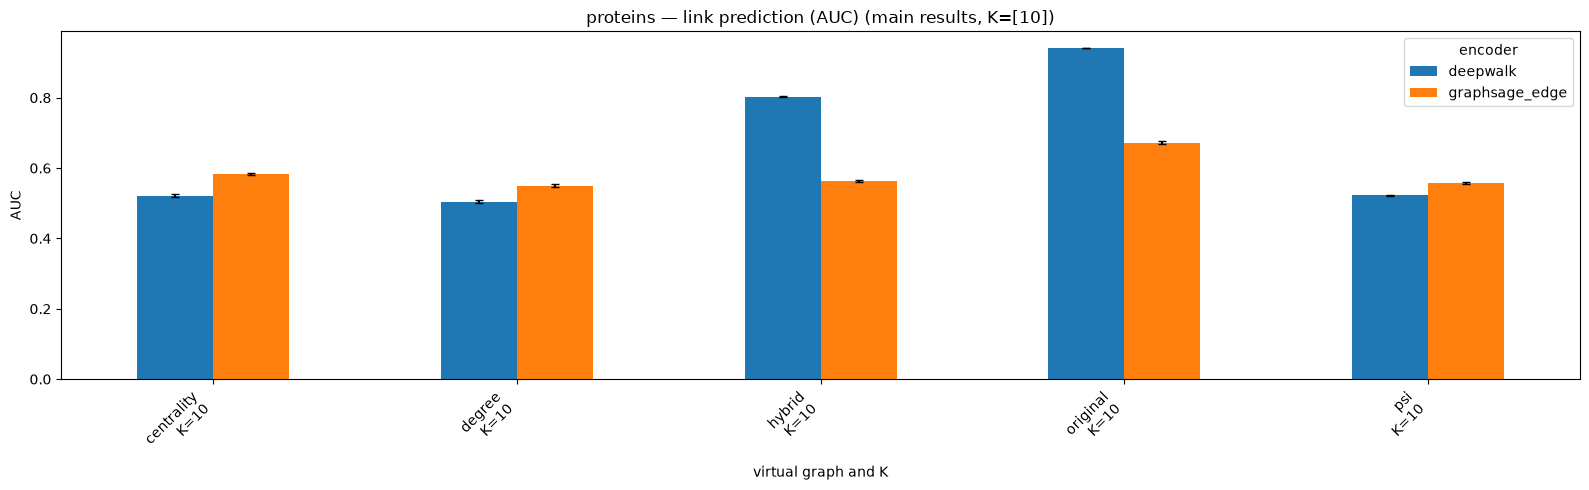

In [13]:
"""Mode 1 — MAIN RESULTS: deepwalk vs graphsage_edge (the locked ViRGo encoder), one table per task."""
sb = Path("results") / "scoreboard.csv"
assert sb.exists(), f"{sb} missing -> run section 6 once first (it records the scores)"
board = pd.read_csv(sb)
MAIN = ["deepwalk", "graphsage_edge"]                                            # main comparison: walk baseline vs locked ViRGo encoder (all other encoders -> Mode 2 below)
VG_ORDER = {"psi": 0, "degree": 1, "centrality": 2, "original": 3, "hybrid": 4}  # row order for the graph variants
SHOW_K = [10]                                                             # <-- K knob: which K values to show, e.g. [5] | [10] | [5, 10, 20]

b = board[(board["dataset"] == DATASET) & (board["encoder"].isin(MAIN)) & (board["top_K_neighbors"].isin(SHOW_K))].copy()
assert not b.empty, f"no scores for {DATASET} at K={SHOW_K} -> pick another SHOW_K, or run section 8 for that K first"
encoders = [e for e in MAIN if e in set(b["encoder"])]

n_graphs = b.groupby(["graph_variant", "top_K_neighbors"]).ngroups
n_tasks = b["task"].nunique()
full = len(encoders) * n_graphs * n_tasks
print(f"{DATASET} MAIN RESULTS (K={SHOW_K}): {len(b)} scores = {len(encoders)} encoders x {n_graphs} virtual graphs x {n_tasks} tasks"
      + ("  -> complete grid, nothing missing" if len(b) == full else f"  -> INCOMPLETE (expected {full}) - missing combos show as NaN below"))

for task in sorted(b["task"].unique(), reverse=True):                            # node classification first, then link prediction
    t = b[b["task"] == task]
    tab = t.pivot_table(index=["graph_variant", "top_K_neighbors"], columns="encoder", values="mean").reindex(columns=encoders)
    tab = tab.reset_index().rename(columns={"top_K_neighbors": "K"}).rename_axis(columns=None)
    tab["_order"] = tab["graph_variant"].map(VG_ORDER).fillna(len(VG_ORDER))
    tab = tab.sort_values(["_order", "K"]).drop(columns="_order").reset_index(drop=True)
    tab["improvement"] = (tab["graphsage_edge"] - tab["deepwalk"]).round(4) if len(encoders) == 2 else np.nan
    tab["winner"] = tab[encoders].idxmax(axis=1)
    print(f"\n=== {task} ===")
    display(tab.round(4))

b["variant"] = b["graph_variant"] + "\nK=" + b["top_K_neighbors"].astype(str)    # charts: same numbers, one picture per task; two-line labels keep all 15 groups readable
for task in sorted(b["task"].unique(), reverse=True):
    t = b[b["task"] == task]
    means = t.pivot_table(index="variant", columns="encoder", values="mean")
    stds = t.pivot_table(index="variant", columns="encoder", values="std")
    ax = means.plot.bar(yerr=stds, figsize=(16, 5), capsize=3, title=f"{DATASET} — {task} (main results, K={SHOW_K})")
    ax.set_xlabel("virtual graph and K"); ax.set_ylabel(task.split("(")[-1].rstrip(")"))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout(); plt.show()

**Reading the tables:** encoder columns = mean over `SEEDS` · `graph_variant`: `psi` (I2V Poisson/KL) | `degree` | `centrality` | `original` (exact copy of the input graph — control) | `hybrid` (original ∪ psi top-K) · `K` = top-K neighbors · `improvement` = `graphsage_edge` − `deepwalk` · `winner` = row's best encoder.


## 8 · Conclusion — which virtual graph is best?

Reuse-or-create ⇒ interruptible: rerunning resumes where it stopped. When done, rerun **§7**.


In [9]:
""" locked encoder over every (graph variant, K) — trains what's missing, records each config to the scoreboard."""
SWEEP_SIMS = ["psi", "degree", "centrality", "original", "hybrid"]        # <-- graph variants to sweep
SWEEP_KS = [10]                              # <-- K values to sweep (full grid; set [10] for a quick single-K pass)

labels = cfg.dataset(DATASET)["labels"]
have_labels = labels is not None and Path(labels).exists()
NC, LP = "node classification (weighted F1)", "link prediction (AUC)"

for sim in SWEEP_SIMS:
    for k in SWEEP_KS:
        vpath = NB2 / "virtual_graphs" / DATASET / f"k{k}" / sim / "virtual_graph.edgelist"
        assert vpath.exists(), f"{vpath} missing -> run notebooks/2-phase_2_virtual_graph.ipynb for sim={sim}, K={k} first"
        Vs = nx.read_weighted_edgelist(vpath, nodetype=int)
        Vs.add_nodes_from(G.nodes)                  # restore isolated nodes dropped by the edgelist format
        got = {NC: [], LP: []}
        for seed in SEEDS:
            split_dir = LP_SPLITS / DATASET / f"seed_{seed}"
            emb = NB3 / "node_classification" / DATASET / f"k{k}" / sim / f"{ENCODER}_s{seed}.emb"
            if not emb.exists() or FORCE_REBUILD:
                print(f"[{sim} K={k}] train NC seed {seed} ...")
                emb.parent.mkdir(parents=True, exist_ok=True)
                enc = SageEncoder(G, Vs, seed, hidden=P["hidden"], dimensions=P["dimensions"], layers=P["layers"], agg=AGG, feats=FEATURES)
                enc.train(P["epochs"], lr=P["lr"], negatives=P["negatives"],
                          pairs_per_epoch=P["pairs_per_epoch"], max_pairs=P["max_pairs"], positives=POSITIVES)
                enc.save(emb)
            if have_labels:
                f1s, _, _ = eval_nodeclass.evaluate(str(emb), str(labels), train_frac=cfg.REPRO["nodeclass_train_frac"], seed=seed)
                got[NC].append(f1s["weighted"])
            lemb = NB3 / "link_prediction" / DATASET / f"k{k}" / sim / f"{ENCODER}_s{seed}.emb"
            if not lemb.exists() or FORCE_REBUILD:
                print(f"[{sim} K={k}] train LP seed {seed} ...")
                lemb.parent.mkdir(parents=True, exist_ok=True)
                Gt = nx.read_edgelist(split_dir / "train.edgelist", nodetype=int, create_using=nx.Graph())
                enc = SageEncoder(Gt, VirtualGraph(Gt).build(sim, k), seed, hidden=P["hidden"], dimensions=P["dimensions"],
                                  layers=P["layers"], agg=AGG, feats=FEATURES)
                enc.train(P["epochs"], lr=P["lr"], negatives=P["negatives"],
                          pairs_per_epoch=P["pairs_per_epoch"], max_pairs=P["max_pairs"], positives=POSITIVES)
                enc.save(lemb)
            got[LP].append(eval_linkpred.evaluate(str(lemb), str(split_dir), seed=seed, score=cfg.REPRO["linkpred_score"]))
        for t in (NC, LP):
            if got[t]:
                results_io.record_score(DATASET, ENCODER, sim, k, t, SEEDS, got[t])
        print(f"[{sim} K={k}] " + (f"NC {np.mean(got[NC]):.4f}  " if got[NC] else "") + f"LP {np.mean(got[LP]):.4f}  -> scoreboard")

        vg = {NC: [], LP: []}                       # deepwalk baseline row: score the SAVED Phase-2 bridge embeddings, never train here
        for seed in SEEDS:
            nemb = NB2 / "node_classification" / DATASET / f"k{k}" / sim / f"deepwalk_s{seed}.emb"
            lemb = NB2 / "link_prediction" / DATASET / f"k{k}" / sim / f"deepwalk_s{seed}.emb"
            if have_labels and nemb.exists():
                f1s, _, _ = eval_nodeclass.evaluate(str(nemb), str(labels), train_frac=cfg.REPRO["nodeclass_train_frac"], seed=seed)
                vg[NC].append(f1s["weighted"])
            if lemb.exists():
                vg[LP].append(eval_linkpred.evaluate(str(lemb), str(LP_SPLITS / DATASET / f"seed_{seed}"),
                                                     seed=seed, score=cfg.REPRO["linkpred_score"]))
        for t in (NC, LP):
            if len(vg[t]) == len(SEEDS):            # record only complete seed sets; partial/missing -> run notebook 2 for this sim/K
                results_io.record_score(DATASET, "deepwalk", sim, k, t, SEEDS, vg[t])
        if len(vg[LP]) == len(SEEDS):
            print(f"[{sim} K={k}] deepwalk " + (f"NC {np.mean(vg[NC]):.4f}  " if len(vg[NC]) == len(SEEDS) else "") + f"LP {np.mean(vg[LP]):.4f}  -> scoreboard")
        else:
            print(f"[{sim} K={k}] deepwalk skipped (bridge embeddings missing -> notebook 2)")
print("sweep done — rerun section 7 to see all variants side by side")

[psi K=10] NC 0.5567  LP 0.5588  -> scoreboard
[psi K=10] deepwalk NC 0.4877  LP 0.5222  -> scoreboard
[degree K=10] train NC seed 42 ...
  epoch   0 | loss 32.2206
  epoch  10 | loss 7.2786
  epoch  20 | loss 4.8555
  epoch  30 | loss 4.3270
  epoch  40 | loss 4.1360
  epoch  49 | loss 4.0836
[degree K=10] train LP seed 42 ...
  epoch   0 | loss 31.4733
  epoch  10 | loss 7.2842
  epoch  20 | loss 4.8938
  epoch  30 | loss 4.3314
  epoch  40 | loss 4.1299
  epoch  49 | loss 4.0849
[degree K=10] train NC seed 43 ...
  epoch   0 | loss 21.1673
  epoch  10 | loss 6.1083
  epoch  20 | loss 4.5962
  epoch  30 | loss 4.1958
  epoch  40 | loss 4.1065
  epoch  49 | loss 4.0634
[degree K=10] train LP seed 43 ...
  epoch   0 | loss 20.3598
  epoch  10 | loss 5.9589
  epoch  20 | loss 4.5533
  epoch  30 | loss 4.1924
  epoch  40 | loss 4.1045
  epoch  49 | loss 4.0594
[degree K=10] train NC seed 44 ...
  epoch   0 | loss 21.8423
  epoch  10 | loss 6.4183
  epoch  20 | loss 4.6456
  epoch  30 | l

## 8b · Ablation D — features or message passing?

GraphSAGE beats the bridge with **two** advantages at once: message passing _and_ four structural input features DeepWalk's lookup table cannot consume. This section separates them.

| id     | features                             | message passing | dims | question                                                                |
| ------ | ------------------------------------ | --------------- | ---- | ----------------------------------------------------------------------- |
| **D0** | degree + centrality + ψ + clustering | ✔ 2-layer       | 4    | the locked ViRGo encoder (**reused from disk, not retrained**)          |
| **D1** | degree                               | ✔               | 1    | is degree alone enough?                                                 |
| **D2** | degree + centrality                  | ✔               | 2    | does centrality add anything?                                           |
| **D3** | ψ                                    | ✔               | 1    | is the I2V scalar enough? _(confounded — the ψ graph was built from ψ)_ |
| **D4** | seeded random                        | ✔               | 4    | **control: message passing with zero structural signal**                |
| **D5** | constant                             | ✔               | 1    | floor — identical rows collapse to zeros, expect AUC ≈ 0.50             |
| **D6** | degree + centrality + ψ + clustering | ✘ `layers=0`    | 4    | **control: the features with zero message passing**                     |

**The 2×2 this closes.** D0 = features + passing · D4 = passing, no features · D6 = features, no passing.

- **D4** answers _are the features necessary?_ — at/below the bridge ⇒ yes, passing alone is not sufficient.
- **D6** answers _does passing add anything?_ — **D6 ≈ D0** ⇒ the GNN adds nothing, the win was the features · **D6 « D0** ⇒ passing earns its place on top of the features.

Neither control alone decides it; the pair does. D6 trains nothing — `layers=0` means the z-normed features **are** the embedding (same feature builder as D0, computed on the 70% train graph for LP ⇒ no leakage).

Artifacts: `graphsage_edge_feat_<set>_s<seed>.emb` and `features_only_s<seed>.emb`; scoreboard encoder names likewise. Snapshot → `results/snapshots/<dataset>_feature_ablation_K<K>.csv`.


In [10]:
"""Ablation D: same graph, same encoder, only the input features change; D6 removes message passing entirely. Trains what's missing, records to the scoreboard."""
D_SETS = ["all", "degree", "deg_cent", "psi", "random", "const"]   # <-- feature sets to run ("all" = D0, reused from disk; "random" = the control)
D_DIMS = {"all": 4, "degree": 1, "deg_cent": 2, "psi": 1, "random": 4, "const": 1}
RUN_D6 = True                                       # <-- D6: raw features straight to the classifier, no GNN — the arm that decides features-vs-message-passing

labels = cfg.dataset(DATASET)["labels"]
have_labels = labels is not None and Path(labels).exists()
NC, LP = "node classification (weighted F1)", "link prediction (AUC)"
vpath = NB2 / "virtual_graphs" / DATASET / f"k{K}" / SIM / "virtual_graph.edgelist"
assert vpath.exists(), f"{vpath} missing -> run notebooks/2-phase_2_virtual_graph.ipynb for sim={SIM}, K={K} first"
Vd = nx.read_weighted_edgelist(vpath, nodetype=int)
Vd.add_nodes_from(G.nodes)                          # restore isolated nodes dropped by the edgelist format

d_rows = []
for feats in D_SETS:
    enc_name = "graphsage_edge" + ("" if feats == "all" else f"_feat_{feats}")   # D0 keeps the locked name -> its embeddings are reused, not retrained
    label, desc = cfg.D_FEATURES[feats]
    got = {NC: [], LP: []}
    for seed in SEEDS:
        split_dir = LP_SPLITS / DATASET / f"seed_{seed}"
        emb = NB3 / "node_classification" / DATASET / f"k{K}" / SIM / f"{enc_name}_s{seed}.emb"
        if not emb.exists() or FORCE_REBUILD:
            print(f"[{label}] train NC seed {seed} ...")
            enc = SageEncoder(G, Vd, seed, hidden=P["hidden"], dimensions=P["dimensions"], layers=P["layers"], agg=AGG, feats=feats)
            enc.train(P["epochs"], lr=P["lr"], negatives=P["negatives"],
                      pairs_per_epoch=P["pairs_per_epoch"], max_pairs=P["max_pairs"], positives=POSITIVES)
            enc.save(emb)
        if have_labels:
            f1s, _, _ = eval_nodeclass.evaluate(str(emb), str(labels), train_frac=cfg.REPRO["nodeclass_train_frac"], seed=seed)
            got[NC].append(f1s["weighted"])
        lemb = NB3 / "link_prediction" / DATASET / f"k{K}" / SIM / f"{enc_name}_s{seed}.emb"
        if not lemb.exists() or FORCE_REBUILD:
            print(f"[{label}] train LP seed {seed} ...")
            Gt = nx.read_edgelist(split_dir / "train.edgelist", nodetype=int, create_using=nx.Graph())
            enc = SageEncoder(Gt, VirtualGraph(Gt).build(SIM, K), seed, hidden=P["hidden"], dimensions=P["dimensions"],
                              layers=P["layers"], agg=AGG, feats=feats)   # features come from the 70% train graph -> no leakage
            enc.train(P["epochs"], lr=P["lr"], negatives=P["negatives"],
                      pairs_per_epoch=P["pairs_per_epoch"], max_pairs=P["max_pairs"], positives=POSITIVES)
            enc.save(lemb)
        got[LP].append(eval_linkpred.evaluate(str(lemb), str(split_dir), seed=seed, score=cfg.REPRO["linkpred_score"]))
    for t in (NC, LP):
        if got[t]:
            results_io.record_score(DATASET, enc_name, SIM, K, t, SEEDS, got[t])
    d_rows.append({"feature_set": label, "dims": D_DIMS[feats],
                   "NC F1": np.mean(got[NC]) if got[NC] else np.nan, "NC std": np.std(got[NC]) if got[NC] else np.nan,
                   "LP AUC": np.mean(got[LP]), "LP std": np.std(got[LP]), "conclusion": desc})
    print(f"[{label}] " + (f"NC {np.mean(got[NC]):.4f}  " if got[NC] else "") + f"LP {np.mean(got[LP]):.4f}  -> scoreboard")

if RUN_D6:                                          # D6: layers=0 -> no convs, the z-normed features ARE the embedding; nothing to train, virtual graph unused
    label, desc = cfg.D_FEATURES["none_mp"]
    got = {NC: [], LP: []}
    for seed in SEEDS:
        split_dir = LP_SPLITS / DATASET / f"seed_{seed}"
        emb = NB3 / "node_classification" / DATASET / f"k{K}" / SIM / f"features_only_s{seed}.emb"
        if not emb.exists() or FORCE_REBUILD:
            print(f"[{label}] build NC seed {seed} (no training) ...")
            SageEncoder(G, G, seed, layers=0, feats="all").save(emb)          # same feature builder as D0, message passing removed
        if have_labels:
            f1s, _, _ = eval_nodeclass.evaluate(str(emb), str(labels), train_frac=cfg.REPRO["nodeclass_train_frac"], seed=seed)
            got[NC].append(f1s["weighted"])
        lemb = NB3 / "link_prediction" / DATASET / f"k{K}" / SIM / f"features_only_s{seed}.emb"
        if not lemb.exists() or FORCE_REBUILD:
            print(f"[{label}] build LP seed {seed} (no training) ...")
            Gt = nx.read_edgelist(split_dir / "train.edgelist", nodetype=int, create_using=nx.Graph())
            SageEncoder(Gt, Gt, seed, layers=0, feats="all").save(lemb)       # features from the 70% train graph -> no leakage
        got[LP].append(eval_linkpred.evaluate(str(lemb), str(split_dir), seed=seed, score=cfg.REPRO["linkpred_score"]))
    for t in (NC, LP):
        if got[t]:
            results_io.record_score(DATASET, "features_only", SIM, K, t, SEEDS, got[t])
    d_rows.append({"feature_set": label, "dims": 4,
                   "NC F1": np.mean(got[NC]) if got[NC] else np.nan, "NC std": np.std(got[NC]) if got[NC] else np.nan,
                   "LP AUC": np.mean(got[LP]), "LP std": np.std(got[LP]), "conclusion": desc})
    print(f"[{label}] " + (f"NC {np.mean(got[NC]):.4f}  " if got[NC] else "") + f"LP {np.mean(got[LP]):.4f}  -> scoreboard")

sb = pd.read_csv(Path("results") / "scoreboard.csv")                             # reference row: read fresh, never retrained here
ref = sb[(sb["dataset"] == DATASET) & (sb["encoder"] == "deepwalk") & (sb["graph_variant"] == SIM) & (sb["top_K_neighbors"] == K)]
ref = {r["task"]: r for _, r in ref.iterrows()}
d = pd.DataFrame([{"feature_set": "deepwalk", "dims": np.nan,
                   "NC F1": ref[NC]["mean"] if NC in ref else np.nan, "NC std": ref[NC]["std"] if NC in ref else np.nan,
                   "LP AUC": ref[LP]["mean"] if LP in ref else np.nan, "LP std": ref[LP]["std"] if LP in ref else np.nan,
                   "conclusion": "reference: no features, no message passing"}] + d_rows)
d0 = d[d["feature_set"] == cfg.D_FEATURES["all"][0]]                             # deltas are measured against the locked encoder (D0)
d["Δ NC"] = (d["NC F1"] - float(d0["NC F1"].iloc[0])).round(4) if len(d0) else np.nan
d["Δ LP"] = (d["LP AUC"] - float(d0["LP AUC"].iloc[0])).round(4) if len(d0) else np.nan

out = Path("results") / "snapshots"; out.mkdir(parents=True, exist_ok=True)
d_csv = out / f"{DATASET}_feature_ablation_K{K}.csv"
d.to_csv(d_csv, index=False)
print(f"\n{DATASET} | ablation D | virtual graph: {SIM}, K={K} | positives: {POSITIVES} | agg: {AGG} | seeds: {SEEDS} — only the input features differ (D6: no message passing)")
print(f"saved -> {d_csv}")
display(d[["feature_set", "dims", "NC F1", "NC std", "LP AUC", "LP std", "Δ NC", "Δ LP", "conclusion"]].round(4))
print("read D4 random vs deepwalk: above the bridge => message passing carries signal; at/below => features are doing the work")
print("read D6 vs D0 (Δ LP): ~0 => message passing adds nothing, the win is the features; strongly negative => the GNN earns its place")

[D0 all] NC 0.5567  LP 0.5588  -> scoreboard
[D1 degree] train NC seed 42 ...
  epoch   0 | loss 47.0152
  epoch  10 | loss 9.2426
  epoch  20 | loss 5.3937
  epoch  30 | loss 4.6532
  epoch  40 | loss 4.2157
  epoch  49 | loss 4.0863
[D1 degree] train LP seed 42 ...
  epoch   0 | loss 48.8599
  epoch  10 | loss 9.6312
  epoch  20 | loss 5.4270
  epoch  30 | loss 4.6789
  epoch  40 | loss 4.2313
  epoch  49 | loss 4.0861
[D1 degree] train NC seed 43 ...
  epoch   0 | loss 85.3268
  epoch  10 | loss 11.7797
  epoch  20 | loss 6.5968
  epoch  30 | loss 4.8393
  epoch  40 | loss 4.3175
  epoch  49 | loss 4.1706
[D1 degree] train LP seed 43 ...
  epoch   0 | loss 86.8989
  epoch  10 | loss 11.8786
  epoch  20 | loss 6.6401
  epoch  30 | loss 4.8729
  epoch  40 | loss 4.3373
  epoch  49 | loss 4.1685
[D1 degree] train NC seed 44 ...
  epoch   0 | loss 38.0160
  epoch  10 | loss 9.2697
  epoch  20 | loss 5.1358
  epoch  30 | loss 4.5456
  epoch  40 | loss 4.1468
  epoch  49 | loss 4.0707
[D1

,feature_set,dims,NC F1,NC std,LP AUC,LP std,Δ NC,Δ LP,conclusion
0,deepwalk,NaN,0.4877,0.0009,0.5222,0.0008,-0.0690,-0.0366,"reference: no features, no message passing"
1,D0 all,4.0,0.5567,0.0024,0.5588,0.0030,0.0000,0.0000,degree + centrality + psi + clustering
2,D1 degree,1.0,0.5058,0.0015,0.5377,0.0034,-0.0509,-0.0212,degree only
3,D2 deg+cent,2.0,0.5340,0.0029,0.5907,0.0051,-0.0228,0.0318,degree + eigenvector centrality
4,D3 psi,1.0,0.4914,0.0016,0.5494,0.0063,-0.0653,-0.0094,psi only (confounded: the psi graph was built ...
5,D4 random,4.0,0.4732,0.0034,0.5122,0.0014,-0.0836,-0.0467,seeded random features - control: message pass...
6,D5 constant,1.0,0.3184,0.0000,0.4407,0.0070,-0.2383,-0.1181,"identical rows -> z-norm zeros - floor, expect..."
7,D6 features only,4.0,0.5216,0.0033,0.5669,0.0010,-0.0352,0.0081,"raw features, no message passing (layers=0) - ..."


read D4 random vs deepwalk: above the bridge => message passing carries signal; at/below => features are doing the work
read D6 vs D0 (Δ LP): ~0 => message passing adds nothing, the win is the features; strongly negative => the GNN earns its place


## 09 · Cross-dataset view

All datasets in the scoreboard **side by side** (columns = dataset × encoder, rows = graph variant). Reads `results/scoreboard.csv` directly — independent of the `DATASET` knob. Display only.


In [11]:
# """Cross-dataset view: every dataset in the scoreboard side by side, main encoders only."""
# XD_K = [10]                                         # <-- K knob: K=10 is the finalized setting (every dataset has the full grid there); [5, 10, 20] shows the cora-only sweep too
# MAIN = ["deepwalk", "graphsage_edge"]
# VG_ORDER = {"psi": 0, "degree": 1, "centrality": 2, "original": 3, "hybrid": 4}

# xb = pd.read_csv(Path("results") / "scoreboard.csv")
# x = xb[(xb["encoder"].isin(MAIN)) & (xb["top_K_neighbors"].isin(XD_K))].copy()
# assert not x.empty, f"no scores at K={XD_K} -> pick another XD_K, or run section 8 for that K first"
# datasets = sorted(x["dataset"].unique())
# print(f"cross-dataset (K={XD_K}): datasets={datasets}, {len(x)} scores — missing combos show as NaN")

# for task in sorted(x["task"].unique(), reverse=True):                            # node classification first, then link prediction
#     t = x[x["task"] == task]
#     tab = t.pivot_table(index=["graph_variant", "top_K_neighbors"], columns=["dataset", "encoder"], values="mean")
#     tab = tab.reindex(columns=pd.MultiIndex.from_product([datasets, MAIN]))      # fixed column order, gaps stay visible
#     tab = tab.reindex([s for s in VG_ORDER if s in tab.index.get_level_values(0)], level=0)
#     tab.index.names = ["graph_variant", "K"]
#     print(f"\n=== {task} ===")
#     display(tab.round(4))

## 10 · Research question — which virtual graph is best?

The **virtual graph is the variable under study** — so the encoder is held fixed at the locked **`graphsage_edge`** (changing graph _and_ encoder together would confound which one caused the result). `original` = **control baseline**, not a ViRGo contribution.

- **Table 1 (PRIMARY):** best virtual/derived graph (psi / degree / centrality / hybrid) per dataset × task, GraphSAGE only — `best_K` names the winning K.
- **Table 2 (CONTROL):** original vs the best virtual graph, GraphSAGE on both sides — does rewiring beat the real edges at all?
- **Secondary question (encoder):** does GraphSAGE beat DeepWalk on the _same_ graph?


In [12]:
# """ViRGo question under the LOCKED encoder: Table 1 = best VIRTUAL graph per dataset x task (graphsage_edge only); Table 2 = control check vs original."""
# RQ_K = [10]                                         # <-- K knob: K=10 is the finalized setting (every dataset has the full grid there); [5, 10, 20] picks the best over the cora-only sweep
# RQ_ENCODER = "graphsage_edge"                       # encoder held fixed (locked via ablations A+B); the encoder question lives in section 7, not here

# rq = pd.read_csv(Path("results") / "scoreboard.csv")
# rq = rq[(rq["encoder"] == RQ_ENCODER) & (rq["top_K_neighbors"].isin(RQ_K))].copy()
# assert not rq.empty, f"no {RQ_ENCODER} scores at K={RQ_K} -> pick another RQ_K, or run section 8 for that K first"
# rq["task"] = rq["task"].map({"node classification (weighted F1)": "NC (F1)", "link prediction (AUC)": "LP (AUC)"})

# # Table 1 — PRIMARY: best virtual/derived graph (psi, degree, centrality, hybrid) per dataset x task, encoder fixed; best over the K sweep.
# virt = rq[rq["graph_variant"] != "original"]
# best_v = virt.loc[virt.groupby(["dataset", "task"])["mean"].idxmax(),
#                   ["dataset", "task", "graph_variant", "top_K_neighbors", "mean"]].reset_index(drop=True)
# t1 = best_v.rename(columns={"graph_variant": "best_virtual_graph", "top_K_neighbors": "best_K", "mean": "graphsage_score"})
# print(f"Table 1 — PRIMARY: which VIRTUAL graph is best per dataset x task? (encoder fixed = {RQ_ENCODER}; best over K={RQ_K}; original excluded = control)")
# display(t1.round(4))

# # Table 2 — CONTROL: original graph vs the best virtual graph, same locked encoder on both sides (original ignores K -> max over its rows).
# orig = rq[rq["graph_variant"] == "original"].groupby(["dataset", "task"])["mean"].max()
# t2 = best_v.set_index(["dataset", "task"])["mean"].rename("best_virtual_score").to_frame()
# t2["original_score"] = orig
# t2 = t2.reset_index()[["dataset", "task", "original_score", "best_virtual_score"]]
# print(f"\nTable 2 — CONTROL check ({RQ_ENCODER} on both sides): does the original graph beat the best virtual graph?")
# display(t2.round(4))